<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [7]:
import piplite
await piplite.install(['numpy', 'pandas', 'seaborn'])

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Import completati con successo")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"seaborn: {sns.__version__}")

✅ Import completati con successo
pandas: 2.2.0
numpy: 1.26.4
seaborn: 0.13.2


In [13]:
import micropip
micropip.list()

Name               | Version     | Source
------------------ | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------
packaging          | 23.2        | pyodide
micropip           | 0.6.0       | pyodide
piplite            | 0.4.0       | https://cf-courses-data.static.labs.skills.network/jupyterlite/2.5.5/extensions/@jupyterlite/pyodide-kernel-extension/static/pypi/piplite-0.4.0-py3-none-any.whl
ipykernel          | 6.9.2       | pypi
comm               | 0.2.3       | pypi
pyodide-kernel     | 0.4.0       | pypi
six                | 1.16.0      | pyodide
decorator          | 5.1.1       | pyodide
asttokens          | 2.4.1       | pyodide
executing          | 2.0.1       | pyodide
wcwidth            | 0.2.13      | pyodide
pure-eval          | 0.2.2       | pyodide
stack-data         | 0.6.3       | pyodide
traitlets          | 5.14.3      | pyodide
matplotlib-inlin

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [14]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


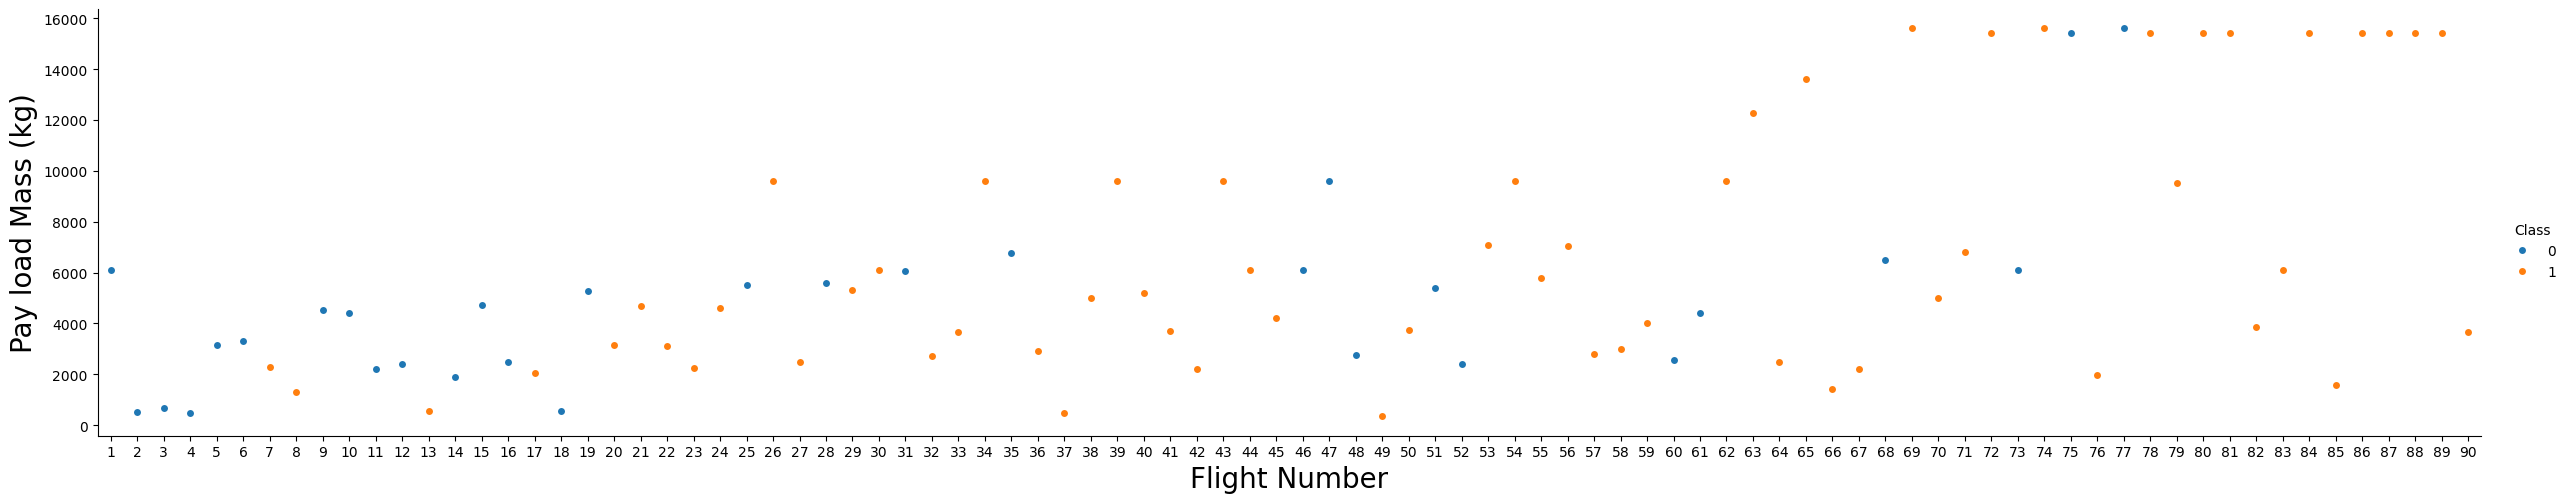

In [15]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']
class
1    60
0    30
Name: count, dtype: int64


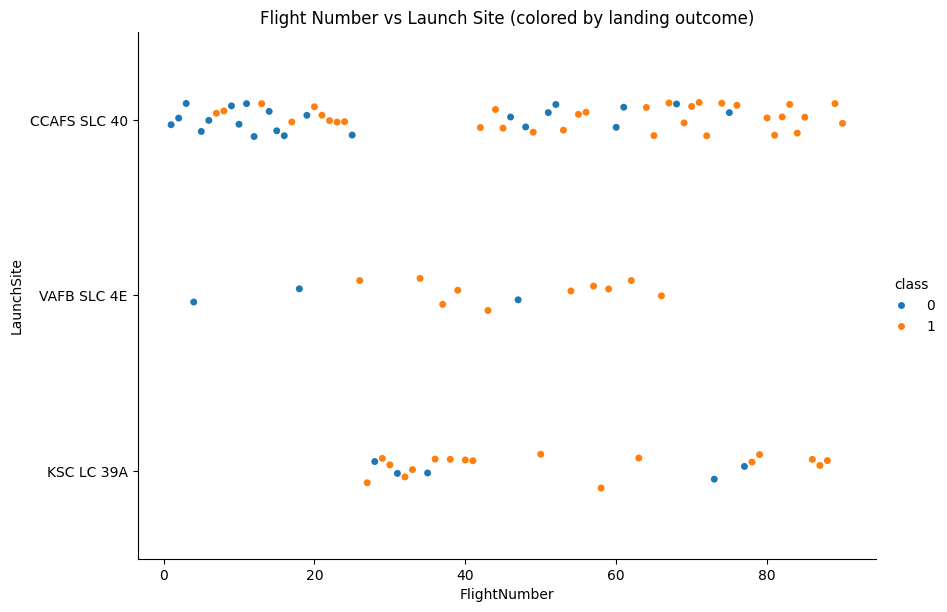

In [17]:
# 1. Verifica colonne
print(df.columns.tolist())

# 2. Crea landing_class
bad_outcomes = {'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}
df['landing_class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)
df['class'] = df['landing_class']

# 3. Verifica distribuzione
print(df['class'].value_counts())

# 4. Crea grafico
sns.catplot(x="FlightNumber", y="LaunchSite", hue="class", data=df, kind="strip", height=6, aspect=1.5)
plt.title("Flight Number vs Launch Site (colored by landing outcome)")
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


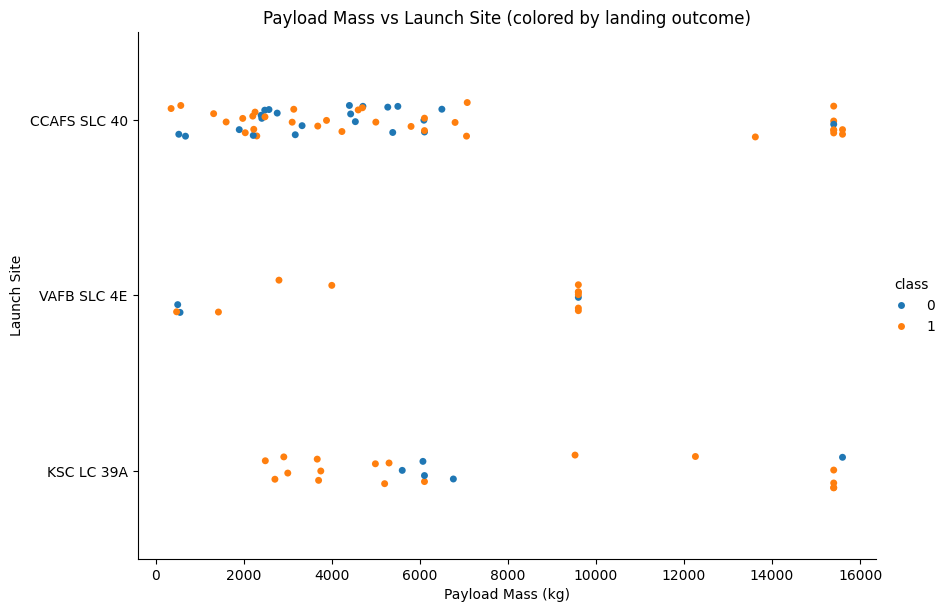

In [18]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Crea il catplot (scatter plot)
sns.catplot(
    x="PayloadMass", 
    y="LaunchSite", 
    hue="class", 
    data=df,
    kind="strip",
    height=6,
    aspect=1.5
)

plt.title("Payload Mass vs Launch Site (colored by landing outcome)")
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


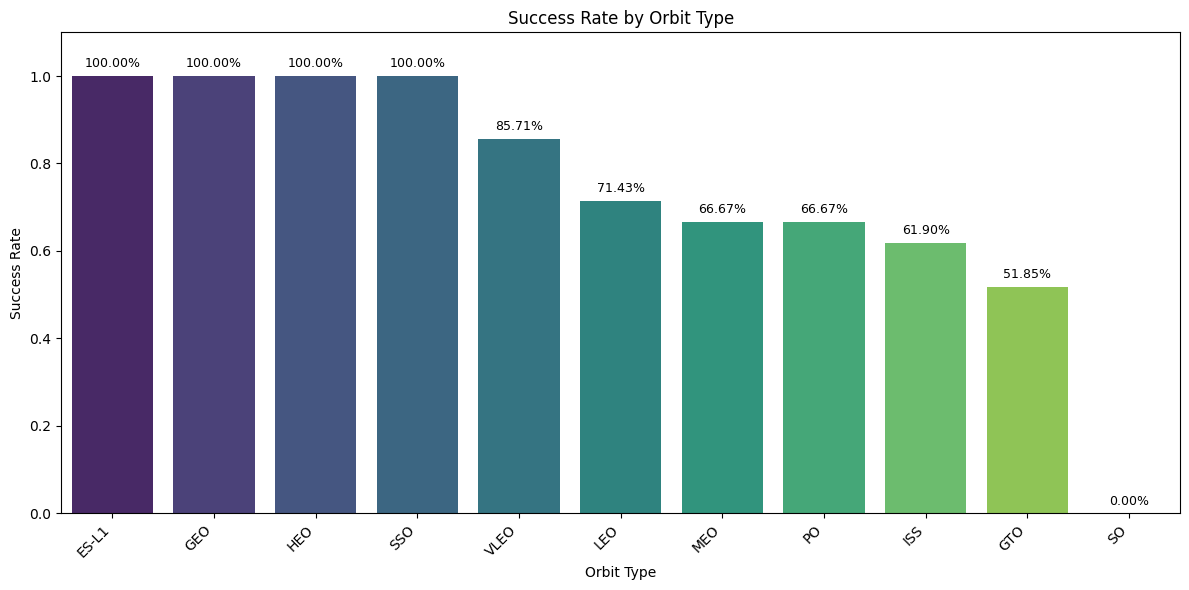

Success Rate by Orbit Type:
Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
MEO      0.666667
PO       0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000
Name: class, dtype: float64


In [21]:
# HINT use groupby method on Orbit column and get the mean of Class column
import seaborn as sns
import matplotlib.pyplot as plt

# Calcola il tasso di successo per ogni orbita
orbit_success_rate = df.groupby('Orbit')['class'].mean().sort_values(ascending=False)

# Crea un DataFrame per il grafico
orbit_success_df = orbit_success_rate.reset_index()
orbit_success_df.columns = ['Orbit', 'Success_Rate']

# Visualizza il grafico a barre (versione aggiornata)
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Orbit', 
    y='Success_Rate', 
    data=orbit_success_df,
    hue='Orbit',           # Aggiungi hue per evitare il deprecation warning
    palette='viridis',
    legend=False           # Nasconde la legenda ridondante
)

plt.title('Success Rate by Orbit Type')
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')

# Aggiungi valori sulle barre
for i, v in enumerate(orbit_success_rate.values):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Stampa i valori
print("Success Rate by Orbit Type:")
print(orbit_success_rate)

Analyze the plotted bar chart to identify which orbits have the highest success rates.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


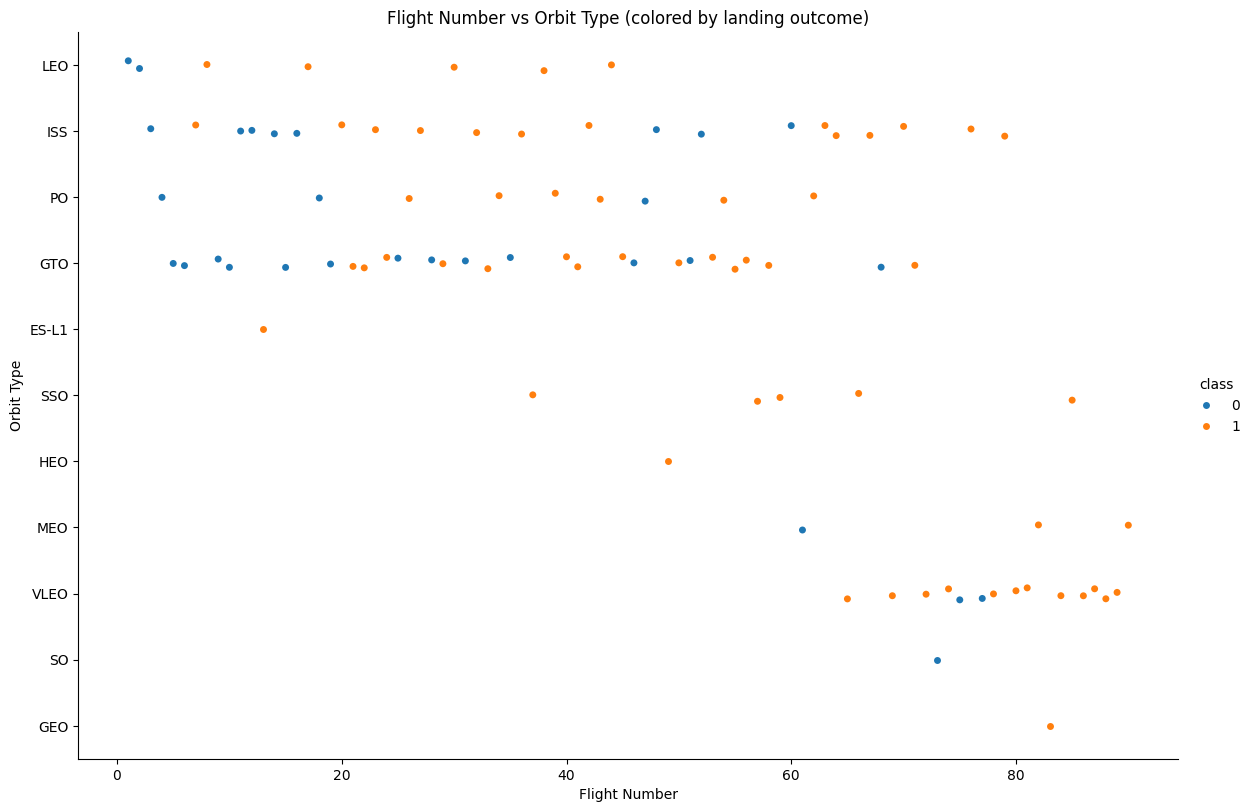

In [22]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Crea il catplot (scatter plot)
sns.catplot(
    x="FlightNumber", 
    y="Orbit", 
    hue="class", 
    data=df,
    kind="strip",
    height=8,
    aspect=1.5,
    jitter=True  # Aggiunge separazione per evitare sovrapposizione
)

plt.title("Flight Number vs Orbit Type (colored by landing outcome)")
plt.xlabel("Flight Number")
plt.ylabel("Orbit Type")
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


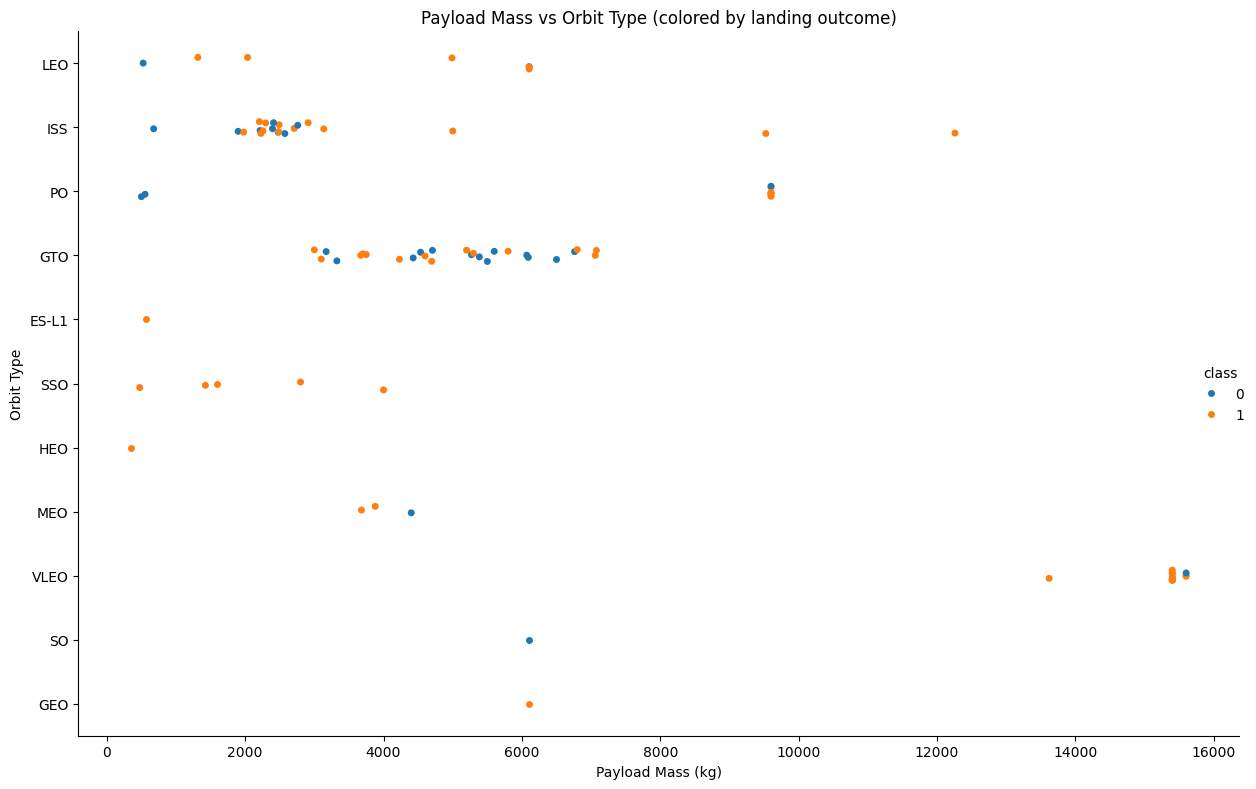

In [24]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class valueimport seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

# Crea il catplot (scatter plot)
plot = sns.catplot(
    x="PayloadMass",
    y="Orbit",
    hue="class",
    data=df,
    kind="strip",
    height=8,
    aspect=1.5,
    jitter=True
)

plt.title("Payload Mass vs Orbit Type (colored by landing outcome)")
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit Type")

# Forza la visualizzazione
plt.tight_layout()
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [25]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,landing_class,class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,0,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,0,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,0,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,0,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,0,0


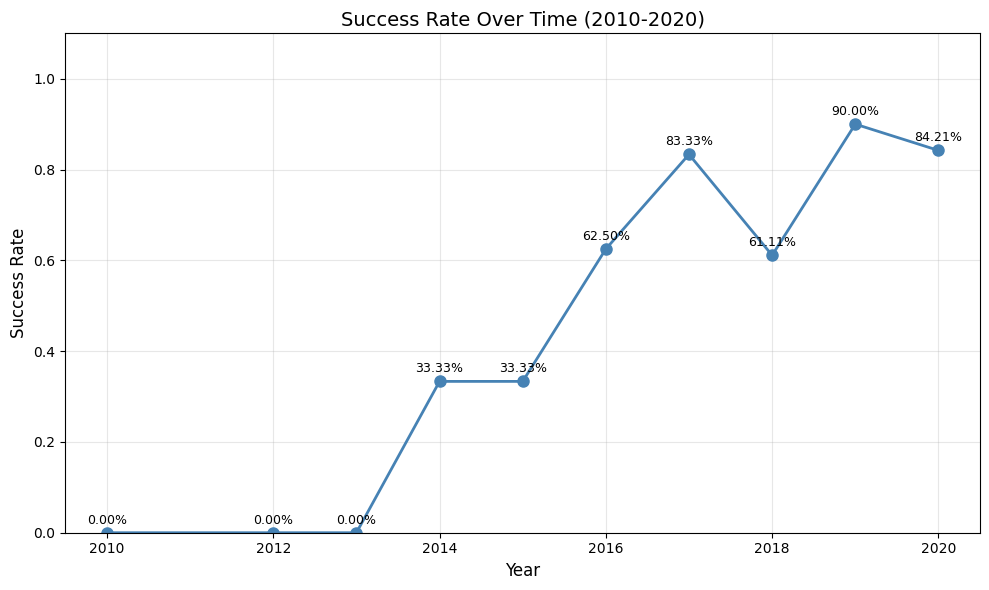

Success Rate by Year:
   Year  Success_Rate
0  2010      0.000000
1  2012      0.000000
2  2013      0.000000
3  2014      0.333333
4  2015      0.333333
5  2016      0.625000
6  2017      0.833333
7  2018      0.611111
8  2019      0.900000
9  2020      0.842105


In [27]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rateimport pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estrai l'anno dalla data
year = []
for i in df["Date"]:
    year.append(i.split("-")[0])
df['Year'] = year

# Calcola il tasso di successo per anno
success_rate_by_year = df.groupby('Year')['class'].mean().reset_index()
success_rate_by_year.columns = ['Year', 'Success_Rate']

# Converti Year in numerico per ordinamento corretto
success_rate_by_year['Year'] = success_rate_by_year['Year'].astype(int)
success_rate_by_year = success_rate_by_year.sort_values('Year')

# Crea il grafico a linee
plt.figure(figsize=(10, 6))
plt.plot(success_rate_by_year['Year'], success_rate_by_year['Success_Rate'], 
         marker='o', linestyle='-', linewidth=2, markersize=8, color='steelblue')

# Aggiungi valori sui punti
for i, row in success_rate_by_year.iterrows():
    plt.text(row['Year'], row['Success_Rate'] + 0.02, 
             f'{row["Success_Rate"]:.2%}', ha='center', fontsize=9)

plt.title('Success Rate Over Time (2010-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stampa i valori
print("Success Rate by Year:")
print(success_rate_by_year)

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [28]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [29]:
# HINT: Use get_dummies() function on the categorical columns
# Seleziona le colonne categoriche da codificare
categorical_columns = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Applica get_dummies per creare variabili dummy
dummies = pd.get_dummies(df[categorical_columns], prefix=categorical_columns)

# Seleziona le colonne numeriche (escludi quelle categoriche e colonne non necessarie)
# Assicurati di escludere anche 'Date' se presente (dopo l'estrazione dell'anno)
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Rimuovi le colonne che sono già state codificate o non necessarie
columns_to_exclude = categorical_columns + ['Date', 'Year']  # Year è già numerico ma lo teniamo
numeric_columns = [col for col in numeric_columns if col not in columns_to_exclude]

# Crea il DataFrame con tutte le features (numeriche + dummy)
features_one_hot = pd.concat([df[numeric_columns], dummies], axis=1)

# Mostra le prime righe
print("Features One-Hot Encoded (prime 5 righe):")
print(features_one_hot.head())

# Mostra anche la forma del DataFrame risultante
print(f"\nShape del DataFrame features_one_hot: {features_one_hot.shape}")
print(f"Numero di colonne totali: {len(features_one_hot.columns)}")

Features One-Hot Encoded (prime 5 righe):
   FlightNumber  PayloadMass  Flights  Block  ReusedCount   Longitude  \
0             1  6104.959412        1    1.0            0  -80.577366   
1             2   525.000000        1    1.0            0  -80.577366   
2             3   677.000000        1    1.0            0  -80.577366   
3             4   500.000000        1    1.0            0 -120.610829   
4             5  3170.000000        1    1.0            0  -80.577366   

    Latitude  Class  landing_class  class  ...  Serial_B1048  Serial_B1049  \
0  28.561857      0              0      0  ...         False         False   
1  28.561857      0              0      0  ...         False         False   
2  28.561857      0              0      0  ...         False         False   
3  34.632093      0              0      0  ...         False         False   
4  28.561857      0              0      0  ...         False         False   

   Serial_B1050  Serial_B1051  Serial_B1054  Seria

### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [30]:
# HINT: use astype function
# Cast di tutte le colonne a float64
features_one_hot = features_one_hot.astype('float64')

# Verifica i tipi di dato
print("Tipi di dato dopo il cast:")
print(features_one_hot.dtypes.value_counts())

# Mostra le prime righe per confermare
print("\nPrime 5 righe di features_one_hot (float64):")
print(features_one_hot.head())

# Mostra anche la forma
print(f"\nShape del DataFrame: {features_one_hot.shape}")

Tipi di dato dopo il cast:
float64    82
Name: count, dtype: int64

Prime 5 righe di features_one_hot (float64):
   FlightNumber  PayloadMass  Flights  Block  ReusedCount   Longitude  \
0           1.0  6104.959412      1.0    1.0          0.0  -80.577366   
1           2.0   525.000000      1.0    1.0          0.0  -80.577366   
2           3.0   677.000000      1.0    1.0          0.0  -80.577366   
3           4.0   500.000000      1.0    1.0          0.0 -120.610829   
4           5.0  3170.000000      1.0    1.0          0.0  -80.577366   

    Latitude  Class  landing_class  class  ...  Serial_B1048  Serial_B1049  \
0  28.561857    0.0            0.0    0.0  ...           0.0           0.0   
1  28.561857    0.0            0.0    0.0  ...           0.0           0.0   
2  28.561857    0.0            0.0    0.0  ...           0.0           0.0   
3  34.632093    0.0            0.0    0.0  ...           0.0           0.0   
4  28.561857    0.0            0.0    0.0  ...           0

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


In [31]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("✅ File esportato: dataset_part_3.csv")
print(f"Shape del dataset esportato: {features_one_hot.shape}")

✅ File esportato: dataset_part_3.csv
Shape del dataset esportato: (90, 82)


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
